# Bipartite Network Graph for SA 4.2: Planetary and Lunar Motion

This notebook creates a bipartite network graph visualizing the relationship between books and content keywords (CKs) related to planetary and lunar motion in the SA 4.2 corpus.

## Visual Specifications:
- **Book Nodes**: Colored by their `place_category` using the standard color mapping.
- **CK Nodes**: Large grey square nodes.
- **CKs Included**:
  - `CK_Stationary and Retrograde Motion` 
  - `CK_Circles of Equant Deferent Epicycle` 
  - `CK_Lunar Orbit` 
  - `CK_Lunar Nodes` 

In [18]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set file paths
book_data_path = '../../DATA/01_corpus_metadata/full_book_data_feb_25.csv'
image_data_path = '../../DATA/02_image_clusters/full_image_data_feb_25.csv'

# Load data
books_df = pd.read_csv(book_data_path)
images_df = pd.read_csv(image_data_path)

print("Data loaded successfully.")

Data loaded successfully.


In [19]:
# Define target CKs for planetary and lunar motion
target_cks = [
    'CK_Stationary and Retrograde Motion',
    'CK_Circles of Equant Deferent Epicycle',
    'CK_Lunar Orbit',
    'CK_Lunar Nodes'
]

# Filter images for these CKs
filtered_images = images_df[images_df['cks'].isin(target_cks)].copy()

# Merge with book data to get place_category
# We drop redundant columns from images side before merging to ensure clean column names in the result.
cols_to_use = books_df[['bid', 'book', 'place_category']].drop_duplicates()
merged_df = pd.merge(
    filtered_images.drop(columns=['place_category'], errors='ignore'), 
    cols_to_use, 
    on=['bid', 'book'], 
    how='left'
)

# Preprocess: Map CKs to unique books
edges = list(set(zip(merged_df['book'], merged_df['cks'])))
book_nodes = merged_df['book'].dropna().unique().tolist()
ck_nodes = merged_df['cks'].dropna().unique().tolist()

print(f"Found {len(book_nodes)} books and {len(ck_nodes)} CKs.")

Found 252 books and 4 CKs.


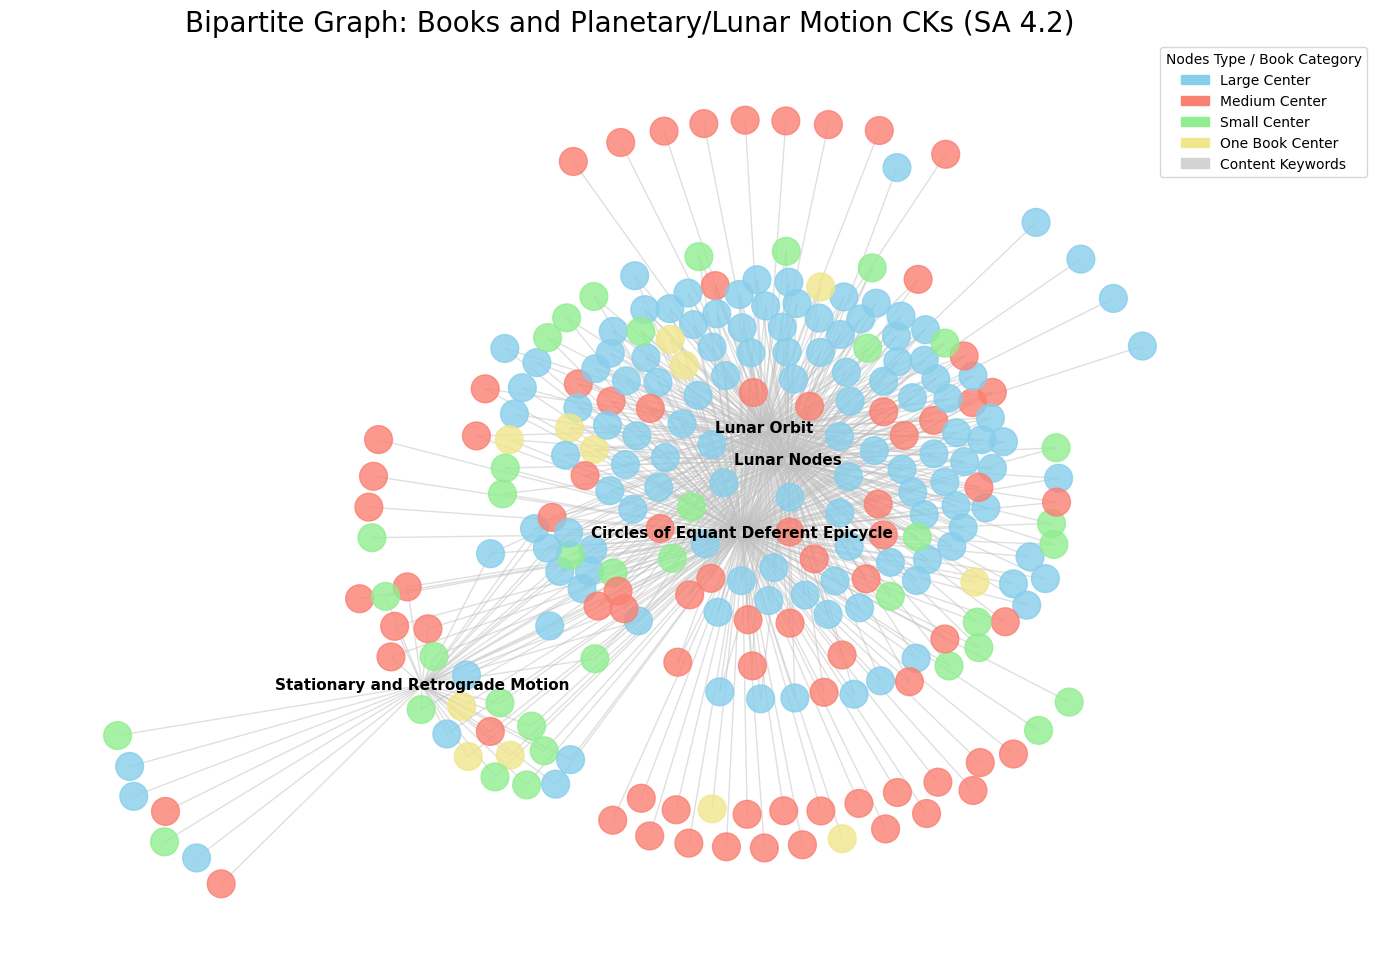

In [25]:
# Set up color mapping for place_category
ordered_categories = ['Large Center', 'Medium Center', 'Small Center', 'One Book Center']
color_palette = ['skyblue', 'salmon', 'lightgreen', 'khaki']
category_color_map = {cat: color for cat, color in zip(ordered_categories, color_palette)}

# Assign colors to book nodes
book_to_category = merged_df.groupby('book')['place_category'].first().to_dict()

# Build Graph
G = nx.Graph()
G.add_nodes_from(book_nodes, bipartite=0)
G.add_nodes_from(ck_nodes, bipartite=1)
G.add_edges_from(edges)

# Draw Graph
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, seed=42, k=0.1, iterations=80)

# Separate node drawing for styling
book_node_colors = [category_color_map.get(book_to_category.get(n, ''), 'lightgrey') for n in book_nodes]

nx.draw_networkx_nodes(G, pos, nodelist=book_nodes, node_color=book_node_colors, node_size=400, alpha=0.8)
nx.draw_networkx_nodes(G, pos, nodelist=ck_nodes, node_color='lightgray', node_shape='s', node_size=5, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color='silver', alpha=0.5)

# Label CK nodes only
nx.draw_networkx_labels(G, pos, labels={node: node.replace('CK_', '') for node in ck_nodes}, font_size=11, font_weight='bold')

# Setup legend
legend_handles = [mpatches.Patch(color=color, label=cat) for cat, color in category_color_map.items()]
legend_handles.append(mpatches.Patch(color='lightgray', label='Content Keywords'))

plt.legend(handles=legend_handles, title="Nodes Type / Book Category", loc='upper right', bbox_to_anchor=(1.1, 1))
plt.title("Bipartite Graph: Books and Planetary/Lunar Motion CKs (SA 4.2)", fontsize=20)
plt.axis('off')

# Save figure
# plt.savefig('SA_4.2_planetary_lunar_motion_network.png', dpi=300, bbox_inches='tight')

# plt.savefig('/Users/nogashlomi/projects/nog_thesis/figures/corrections_round/planetary_motion_network.png', dpi=300)


plt.show()